# M3 — Optimización de Carteras

**Roboadvisor TFM.** Este notebook transforma los inputs históricos del M2 en tres carteras óptimas — una por perfil de riesgo (conservador, moderado, agresivo) — aplicando restricciones UCITS y caps de volatilidad. Salida: `weights.parquet` y `portfolios_summary.json`, consumidos por M4 (backtesting walk-forward).

## Bloque 0 — Setup y carga de datos

In [1]:
# --- roboadvisor_paths bootstrap (auto-inserted) ---
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()


In [2]:
from __future__ import annotations

import json
import logging
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = PATHS.NOTEBOOKS_DIR
PACKAGE_ROOT = PATHS.PROJECT_ROOT  # legacy alias

from m3_portfolio import (  # noqa: E402
    CASH_TICKER,
    EqualWeightOptimizer,
    HRPOptimizer,
    MaxSharpeOptimizer,
    MinVarianceOptimizer,
    Portfolio,
    RISK_FREE_RATE,
    TRADING_DAYS,
    validate_portfolio,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(name)s %(levelname)s %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("m3_notebook")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


In [3]:
PROFILES: dict[str, list[str]] = {
    "conservador": ["IEAG.AS", "EUNH.DE", "IBCI.AS"],
    "moderado":    ["INFR.AS", "IHYG.L", "EXSA.DE"],
    "agresivo":    ["CSPX.L", "EQQQ.DE", "EXI2.DE"],
}

MAX_VOL: dict[str, float] = {
    "conservador": 0.08,
    "moderado":    0.15,
    "agresivo":    0.25,
}

PRIMARY_OPTIMIZER: dict[str, type] = {
    "conservador": MinVarianceOptimizer,
    "moderado":    MaxSharpeOptimizer,
    "agresivo":    HRPOptimizer,
}

# Estrategia alternativa por perfil (segunda candidata).
ALTERNATIVE_OPTIMIZER: dict[str, type] = {
    "conservador": MaxSharpeOptimizer,
    "moderado":    HRPOptimizer,
    "agresivo":    MaxSharpeOptimizer,
}

# Baseline transversal: equal weight.
BASELINE_OPTIMIZER = EqualWeightOptimizer


In [4]:
ETF_DIR = PATHS.M2_OUTPUTS_DIR

returns = pd.read_parquet(ETF_DIR / "returns.parquet")
with open(ETF_DIR / "mu.pkl", "rb") as fh:
    mu = pickle.load(fh)
with open(ETF_DIR / "cov_ledoit_wolf.pkl", "rb") as fh:
    cov = pickle.load(fh)

# Normalise mu/cov to pandas with consistent ticker order.
if not isinstance(mu, pd.Series):
    mu = pd.Series(mu, index=returns.columns)
if not isinstance(cov, pd.DataFrame):
    cov = pd.DataFrame(cov, index=returns.columns, columns=returns.columns)

all_tickers = sorted({t for tks in PROFILES.values() for t in tks})
missing = [t for t in all_tickers if t not in mu.index or t not in cov.index]
assert not missing, f"Tickers ausentes en mu/cov: {missing}"

print(f"returns: {returns.shape}, periodo {returns.index.min().date()} → {returns.index.max().date()}")
print(f"mu: {mu.shape}, cov: {cov.shape}")


returns: (4016, 9), periodo 2010-09-16 → 2026-05-12
mu: (9,), cov: (9, 9)


## Bloque 1 — Estrategias por perfil

Asignación principal y alternativa que se comparan en § 2.

| Perfil | Vol cap | Optimizador principal | Alternativo | Baseline |
|--------|---------|-----------------------|-------------|----------|
| Conservador | 8%  | Mínima varianza | Máximo Sharpe | Equal-weight |
| Moderado    | 15% | Máximo Sharpe   | HRP            | Equal-weight |
| Agresivo    | 25% | HRP             | Máximo Sharpe  | Equal-weight |

HRP entra en agresivo porque las colas pesadas y la asimetría negativa documentadas en M2 (kurtosis exceso > 3 en los 9 ETFs) debilitan los supuestos de normalidad de Markowitz. Cuando la cartera optimizada excede el `max_vol` del perfil, se mezcla linealmente con cash (rf=2%) hasta cumplir el cap.

## Bloque 2 — Optimización: carteras candidatas

Por cada perfil generamos 3 candidatas (principal, alternativa, equal-weight).

In [5]:
candidates: dict[str, dict[str, Portfolio]] = {}

for profile, tickers in PROFILES.items():
    candidates[profile] = {}
    cap = MAX_VOL[profile]
    for label, OptCls in [
        ("principal", PRIMARY_OPTIMIZER[profile]),
        ("alternativo", ALTERNATIVE_OPTIMIZER[profile]),
        ("baseline", BASELINE_OPTIMIZER),
    ]:
        optimizer = OptCls()
        portfolio = optimizer.optimize(
            mu=mu,
            cov=cov,
            tickers=tickers,
            max_volatility=cap,
            profile=profile,
            risk_free_rate=RISK_FREE_RATE,
        )
        candidates[profile][label] = portfolio
        print(f"[{profile:<11} | {label:<11}] {portfolio}")


14:44:32 m3_portfolio.min_variance INFO MinVariance optimize [conservador]: n_assets=3, vol_cap=8.00%


14:44:32 m3_portfolio._build INFO Built Portfolio(profile='conservador', optimizer='min_variance', ret=1.22%, vol=4.35%, sharpe=-0.179, cash=0.00%, hhi=0.855, n_eff=2)


14:44:32 m3_portfolio.max_sharpe INFO MaxSharpe optimize [conservador]: n_assets=3, vol_cap=8.00%, rf=2.00%


14:44:32 m3_portfolio.max_sharpe WARNING Max(mu)=0.0172 <= rf=0.0200; max_sharpe is undefined. Falling back to min_volatility for profile=conservador.


14:44:32 m3_portfolio._build INFO Built Portfolio(profile='conservador', optimizer='max_sharpe', ret=1.22%, vol=4.35%, sharpe=-0.179, cash=0.00%, hhi=0.855, n_eff=2)


...

14:44:32 m3_portfolio.max_sharpe INFO MaxSharpe optimize [agresivo]: n_assets=3, vol_cap=25.00%, rf=2.00%


14:44:32 m3_portfolio._build INFO Built Portfolio(profile='agresivo', optimizer='max_sharpe', ret=17.34%, vol=16.84%, sharpe=0.910, cash=0.00%, hhi=0.500, n_eff=2)


14:44:32 m3_portfolio.equal_weight INFO EqualWeight optimize [agresivo]: n_assets=3, vol_cap=25.00%


14:44:32 m3_portfolio._build INFO Built Portfolio(profile='agresivo', optimizer='equal_weight', ret=16.26%, vol=16.11%, sharpe=0.885, cash=0.00%, hhi=0.333, n_eff=3)


[conservador | principal  ] Portfolio(profile='conservador', optimizer='min_variance', ret=1.22%, vol=4.35%, sharpe=-0.179, cash=0.00%, hhi=0.855, n_eff=2)
[conservador | alternativo] Portfolio(profile='conservador', optimizer='max_sharpe', ret=1.22%, vol=4.35%, sharpe=-0.179, cash=0.00%, hhi=0.855, n_eff=2)
[conservador | baseline   ] Portfolio(profile='conservador', optimizer='equal_weight', ret=1.39%, vol=4.68%, sharpe=-0.129, cash=0.00%, hhi=0.333, n_eff=3)
[moderado    | principal  ] Portfolio(profile='moderado', optimizer='max_sharpe', ret=8.26%, vol=14.09%, sharpe=0.444, cash=0.00%, hhi=0.533, n_eff=2)
[moderado    | alternativo] Portfolio(profile='moderado', optimizer='hrp', ret=4.30%, vol=7.11%, sharpe=0.323, cash=0.00%, hhi=0.672, n_eff=3)
[moderado    | baseline   ] Portfolio(profile='moderado', optimizer='equal_weight', ret=6.50%, vol=10.55%, sharpe=0.427, cash=0.00%, hhi=0.333, n_eff=3)
[agresivo    | principal  ] Portfolio(profile='agresivo', optimizer='hrp', ret=15.27%, 

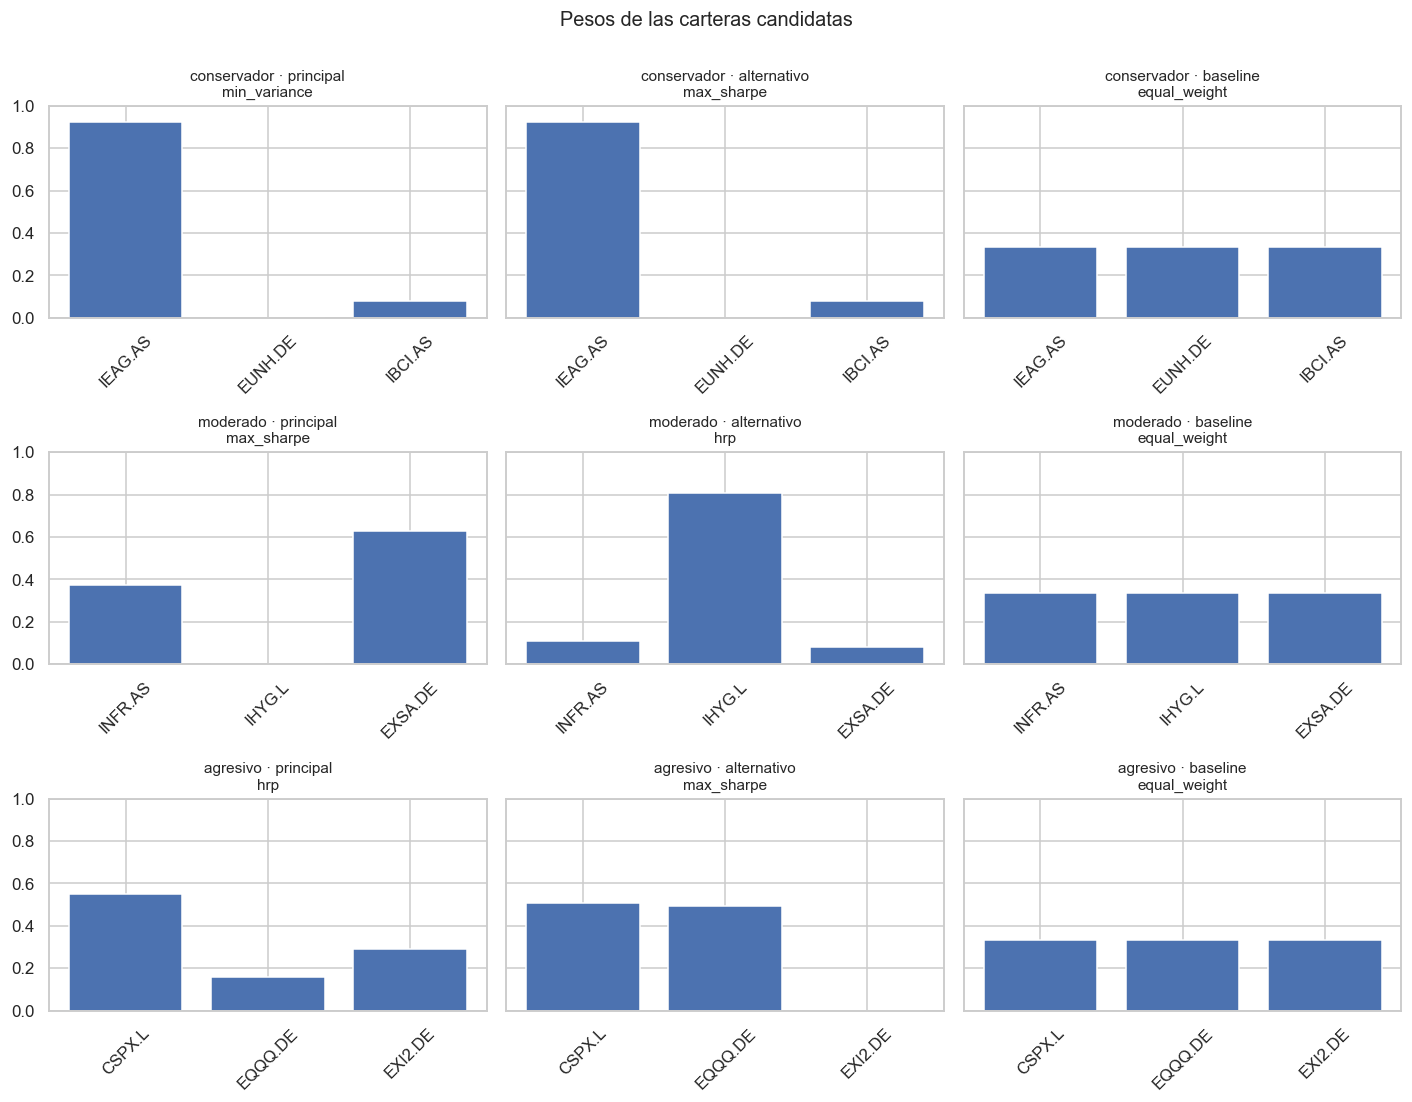

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharey=True)
labels_order = ["principal", "alternativo", "baseline"]
for i, (profile, tickers) in enumerate(PROFILES.items()):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        p = candidates[profile][label]
        keys = list(tickers) + ([CASH_TICKER] if p.cash_weight > 0 else [])
        vals = [p.weights.get(k, 0.0) for k in keys]
        colors = ["#4c72b0" if k != CASH_TICKER else "#bbbbbb" for k in keys]
        ax.bar(keys, vals, color=colors)
        ax.set_title(f"{profile} · {label}\n{p.optimizer_name}", fontsize=10)
        ax.set_ylim(0, 1.0)
        ax.tick_params(axis="x", labelrotation=45)
fig.suptitle("Pesos de las carteras candidatas", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()


## Bloque 3 — Tabla comparativa

Métricas ex-ante (μ y covarianza históricos M2). Criterio de selección: **máximo Sharpe sujeto a `vol_actual ≤ vol_cap × 1.01`**.

In [7]:
rows = []
for profile, opts in candidates.items():
    cap = MAX_VOL[profile]
    for label, p in opts.items():
        rows.append({
            "perfil": profile,
            "candidata": label,
            "optimizador": p.optimizer_name,
            "ret_esperado_%": p.expected_return * 100,
            "vol_esperada_%": p.expected_volatility * 100,
            "vol_cap_%": cap * 100,
            "sharpe": p.expected_sharpe,
            "HHI": p.herfindahl_index,
            "n_activos_efectivos": p.n_effective_assets,
            "cash_%": p.cash_weight * 100,
            "cumple_vol_cap": p.expected_volatility <= cap * 1.01,
        })
comparison = pd.DataFrame(rows)
comparison.style.format({
    "ret_esperado_%": "{:.2f}",
    "vol_esperada_%": "{:.2f}",
    "vol_cap_%": "{:.2f}",
    "sharpe": "{:.3f}",
    "HHI": "{:.3f}",
    "cash_%": "{:.2f}",
})


,perfil,candidata,optimizador,ret_esperado_%,vol_esperada_%,vol_cap_%,sharpe,HHI,n_activos_efectivos,cash_%,cumple_vol_cap
0,conservador,principal,min_variance,1.22,4.35,8.00,-0.179,0.855,2,0.00,True
1,conservador,alternativo,max_sharpe,1.22,4.35,8.00,-0.179,0.855,2,0.00,True
2,conservador,baseline,equal_weight,1.39,4.68,8.00,-0.129,0.333,3,0.00,True
3,moderado,principal,max_sharpe,8.26,14.09,15.00,0.444,0.533,2,0.00,True
4,moderado,alternativo,hrp,4.30,7.11,15.00,0.323,0.672,3,0.00,True
5,moderado,baseline,equal_weight,6.50,10.55,15.00,0.427,0.333,3,0.00,True
6,agresivo,principal,hrp,15.27,15.22,25.00,0.872,0.412,3,0.00,True
7,agresivo,alternativo,max_sharpe,17.34,16.84,25.00,0.910,0.500,2,0.00,True
8,agresivo,baseline,equal_weight,16.26,16.11,25.00,0.885,0.333,3,0.00,True


## Bloque 4 — Selección final

Para cada perfil, elegimos la candidata con **mayor Sharpe** entre las que cumplen el vol cap.

In [8]:
def pick_best(opts: dict[str, Portfolio], cap: float) -> tuple[str, Portfolio]:
    feasible = {l: p for l, p in opts.items() if p.expected_volatility <= cap * 1.01}
    pool = feasible if feasible else opts
    best_label = max(pool, key=lambda l: pool[l].expected_sharpe)
    return best_label, pool[best_label]

selected: dict[str, Portfolio] = {}
selection_log: dict[str, str] = {}
for profile, opts in candidates.items():
    label, portfolio = pick_best(opts, MAX_VOL[profile])
    selected[profile] = portfolio
    selection_log[profile] = label
    print(f"[{profile}] elegida: {label} ({portfolio.optimizer_name}) — sharpe={portfolio.expected_sharpe:.3f}")


[conservador] elegida: baseline (equal_weight) — sharpe=-0.129
[moderado] elegida: principal (max_sharpe) — sharpe=0.444
[agresivo] elegida: alternativo (max_sharpe) — sharpe=0.910


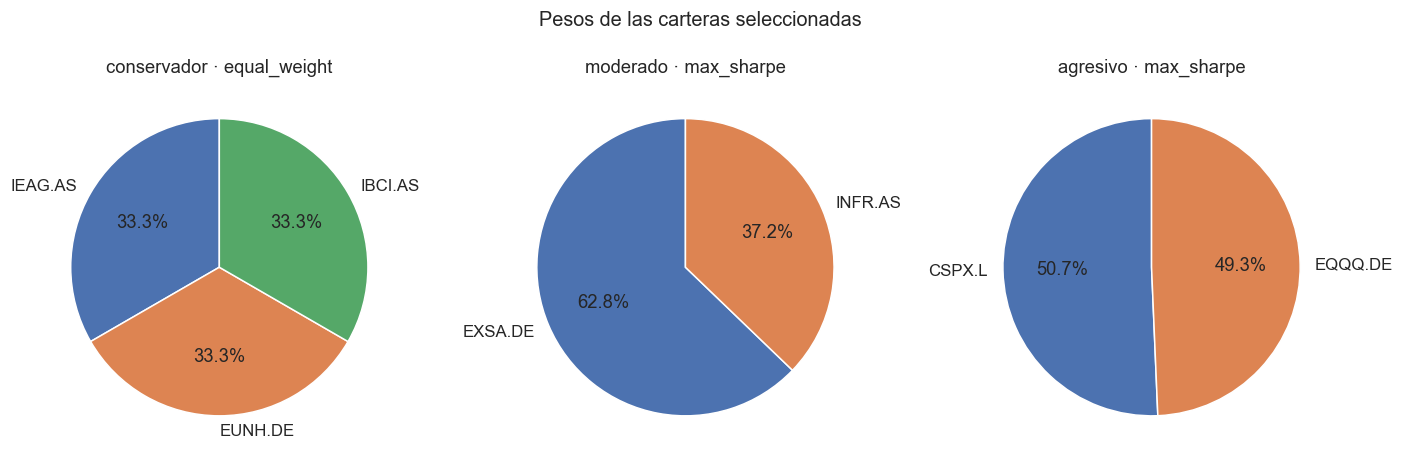

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (profile, p) in zip(axes, selected.items()):
    items = [(k, v) for k, v in p.weights.items() if v > 1e-4]
    items.sort(key=lambda kv: -kv[1])
    labels = [k for k, _ in items]
    sizes = [v for _, v in items]
    colors = ["#bbbbbb" if k == CASH_TICKER else None for k in labels]
    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90,
           colors=colors if any(c for c in colors) else None)
    ax.set_title(f"{profile} · {p.optimizer_name}")
fig.suptitle("Pesos de las carteras seleccionadas", fontsize=13)
fig.tight_layout()
plt.show()


In [10]:
summary_rows = []
for profile, p in selected.items():
    summary_rows.append({
        "perfil": profile,
        "optimizador": p.optimizer_name,
        "ret_%": p.expected_return * 100,
        "vol_%": p.expected_volatility * 100,
        "vol_cap_%": MAX_VOL[profile] * 100,
        "sharpe": p.expected_sharpe,
        "HHI": p.herfindahl_index,
        "n_eff": p.n_effective_assets,
        "cash_%": p.cash_weight * 100,
        "pesos": p.weight_string(),
    })
summary = pd.DataFrame(summary_rows)
summary


,perfil,optimizador,ret_%,vol_%,vol_cap_%,sharpe,HHI,n_eff,cash_%,pesos
0,conservador,equal_weight,1.394245,4.679677,8.0,-0.129444,0.333333,3,0.0,IEAG.AS 33.3% | EUNH.DE 33.3% | IBCI.AS 33.3%
1,moderado,max_sharpe,8.262021,14.094781,15.0,0.444279,0.532791,2,0.0,EXSA.DE 62.8% | INFR.AS 37.2%
2,agresivo,max_sharpe,17.335710,16.843484,25.0,0.910483,0.500091,2,0.0,CSPX.L 50.7% | EQQQ.DE 49.3%


## Bloque 5 — Validación UCITS y volatilidad

Chequeos: suma de pesos = 1, long-only, vol respeta cap, HHI en rango.

In [11]:
validation_rows = []
for profile, p in selected.items():
    report = validate_portfolio(p, cov, PROFILES[profile], MAX_VOL[profile])
    validation_rows.append({"perfil": profile, **report,
                            "STATUS": "PASS" if all(report.values()) else "FAIL"})
validation_df = pd.DataFrame(validation_rows)
validation_df


14:44:34 m3_portfolio.validators INFO Validation conservador: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation moderado: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation agresivo: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


,perfil,sum_to_one,long_only,vol_within_cap,hhi_in_range,STATUS
0,conservador,True,True,True,True,PASS
1,moderado,True,True,True,True,PASS
2,agresivo,True,True,True,True,PASS


## Bloque 6 — Export para M4

Persistimos pesos (parquet multi-índice) y resumen (JSON).

In [12]:
OUTPUT_DIR = PATHS.M3_OUTPUTS_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

weights_rows = []
for profile, p in selected.items():
    for ticker, w in p.weights.items():
        weights_rows.append({"profile": profile, "ticker": ticker, "weight": w})
weights_df = pd.DataFrame(weights_rows).set_index(["profile", "ticker"]).sort_index()
weights_path = OUTPUT_DIR / "weights.parquet"
weights_df.to_parquet(weights_path)
print(f"Saved weights → {weights_path}")
weights_df


Saved weights → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m3\weights.parquet


weight
profile     ticker           
agresivo    CSPX.L   0.506730
            EQQQ.DE  0.493270
            EXI2.DE  0.000000
conservador EUNH.DE  0.333333
            IBCI.AS  0.333333
            IEAG.AS  0.333333
moderado    EXSA.DE  0.628045
            IHYG.L   0.000000
            INFR.AS  0.371955

In [13]:
summary_dict: dict[str, dict] = {}
for profile, p in selected.items():
    report = validate_portfolio(p, cov, PROFILES[profile], MAX_VOL[profile])
    summary_dict[profile] = {
        "optimizer": p.optimizer_name,
        "selection": selection_log[profile],
        "weights": {k: float(v) for k, v in p.weights.items()},
        "cash_weight": float(p.cash_weight),
        "expected_return": float(p.expected_return),
        "expected_volatility": float(p.expected_volatility),
        "expected_sharpe": float(p.expected_sharpe),
        "herfindahl_index": float(p.herfindahl_index),
        "n_effective_assets": int(p.n_effective_assets),
        "max_volatility": float(MAX_VOL[profile]),
        "validation": report,
    }
summary_path = OUTPUT_DIR / "portfolios_summary.json"
with open(summary_path, "w", encoding="utf-8") as fh:
    json.dump(summary_dict, fh, indent=2, ensure_ascii=False)
print(f"Saved summary → {summary_path}")


14:44:34 m3_portfolio.validators INFO Validation conservador: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation moderado: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation agresivo: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


Saved summary → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m3\portfolios_summary.json


In [14]:
checklist = {
    "weights.parquet existe": weights_path.exists(),
    "portfolios_summary.json existe": summary_path.exists(),
    "3 perfiles seleccionados": len(selected) == 3,
    "Validación PASS en los 3 perfiles": all(
        all(validate_portfolio(p, cov, PROFILES[prof], MAX_VOL[prof]).values())
        for prof, p in selected.items()
    ),
    "Pesos suman 1 ± 1e-6": all(
        abs(sum(p.weights.values()) - 1.0) < 1e-6 for p in selected.values()
    ),
}
for k, v in checklist.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")


14:44:34 m3_portfolio.validators INFO Validation conservador: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation moderado: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


14:44:34 m3_portfolio.validators INFO Validation agresivo: {'sum_to_one': True, 'long_only': True, 'vol_within_cap': True, 'hhi_in_range': True}


  [PASS] weights.parquet existe
  [PASS] portfolios_summary.json existe
  [PASS] 3 perfiles seleccionados
  [PASS] Validación PASS en los 3 perfiles
  [PASS] Pesos suman 1 ± 1e-6


## Bloque 9 — Nota sobre validación temporal

Los pesos generados en este notebook usan **μ y Σ estimados sobre el histórico completo** (`returns.parquet`, 2010-09 → 2026-05). Representan la cartera que el roboadvisor recomendaría **hoy** con toda la información disponible — es el output canónico de M3 para el inversor real.

La **validación walk-forward** de estos pesos sobre el periodo OOS 2020-2026 se realiza en M4, donde se **regeneran pesos OOS-clean** con μ y Σ restringidos a 2010-2019. Esto garantiza ausencia de *look-ahead bias* en la fase de estimación de parámetros y permite comparar:

- **Cartera ex-ante (M3):** `outputs/m3/weights.parquet` — μ/Σ sobre todo el histórico, autoridad sobre *"qué recomendar hoy"*.
- **Cartera OOS-clean (M4):** `outputs/m4/weights_oos_clean.parquet` — μ/Σ ≤ 2019-12-31, autoridad sobre *"qué se habría recomendado en 2019 y cómo se comportó"*.

Ambas carteras conviven legítimamente y cumplen funciones disjuntas. La separación de responsabilidades (M3 = optimización in-sample, M4 = validación walk-forward) hace el backtest académicamente defendible.